# Asset Price Modeling — Standalone (Simple)

**Self-contained, no type hints — pure executable logic only.**

Simplified version of `asset_price_modeling_standalone.ipynb`.
All type annotations (`-> np.ndarray`, `: int`, `: float`, etc.) are removed.

## Requirements

```bash
pip install numpy matplotlib yfinance
```

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf

plt.style.use("seaborn-v0_8")

## 1) Symmetric Random Walk

$$
X_j = \begin{cases}
+1, & \mathbb{P}=\tfrac{1}{2} \\
-1, & \mathbb{P}=\tfrac{1}{2}
\end{cases},\qquad
M_k = \sum_{j=1}^{k}X_j, \quad M_0=0.
$$

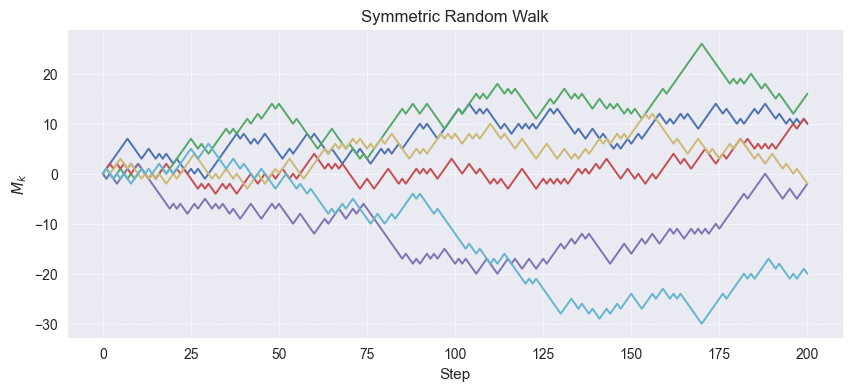

In [2]:
def simulate_symmetric_random_walk(n_steps, n_paths=1, start=0.0, seed=None):
    rng = np.random.default_rng(seed)
    increments = rng.choice(np.array([-1.0, 1.0]), size=(n_paths, n_steps))
    cumulative = np.cumsum(increments, axis=1)
    start_col = np.full((n_paths, 1), float(start))
    return np.concatenate([start_col, float(start) + cumulative], axis=1)


rw_paths = simulate_symmetric_random_walk(n_steps=200, n_paths=6, seed=7)

fig, ax = plt.subplots(figsize=(10, 4))
for i in range(rw_paths.shape[0]):
    ax.plot(rw_paths[i], linewidth=1.4)
ax.set_title("Symmetric Random Walk")
ax.set_xlabel("Step")
ax.set_ylabel("$M_k$")
ax.grid(True, linestyle="--", linewidth=0.5)
plt.show()

## 2) Brownian Motion

$$
W(t_{i+1}) - W(t_i) \sim \mathcal{N}(0,\, t_{i+1}-t_i).
$$

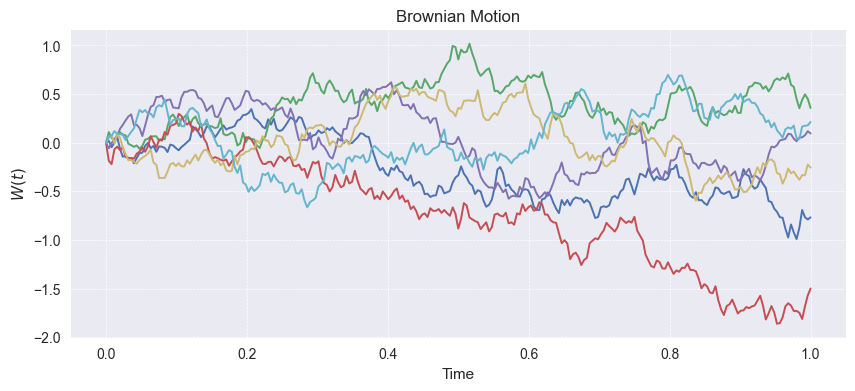

In [3]:
def simulate_brownian_motion(n_steps, horizon=1.0, n_paths=1, start=0.0, seed=None):
    dt = horizon / n_steps
    rng = np.random.default_rng(seed)
    increments = rng.normal(loc=0.0, scale=np.sqrt(dt), size=(n_paths, n_steps))
    cumulative = np.cumsum(increments, axis=1)
    start_col = np.full((n_paths, 1), float(start))
    return np.concatenate([start_col, float(start) + cumulative], axis=1)


n_steps = 252
horizon = 1.0
time_axis = np.linspace(0.0, horizon, n_steps + 1)
bm_paths = simulate_brownian_motion(
    n_steps=n_steps,
    horizon=horizon,
    n_paths=6,
    seed=42,
)

fig, ax = plt.subplots(figsize=(10, 4))
for i in range(bm_paths.shape[0]):
    ax.plot(time_axis, bm_paths[i], linewidth=1.4)
ax.set_title("Brownian Motion")
ax.set_xlabel("Time")
ax.set_ylabel("$W(t)$")
ax.grid(True, linestyle="--", linewidth=0.5)
plt.show()

## 3) Geometric Brownian Motion (GBM)

$$
\frac{dS(t)}{S(t)} = \alpha\, dt + \sigma\, dW(t).
$$

Discretized log-return form:

$$
\Delta\log S \approx \left(\alpha-\frac{1}{2}\sigma^2\right)\Delta t
+ \sigma\sqrt{\Delta t}\,Z,\quad Z\sim\mathcal{N}(0,1).
$$

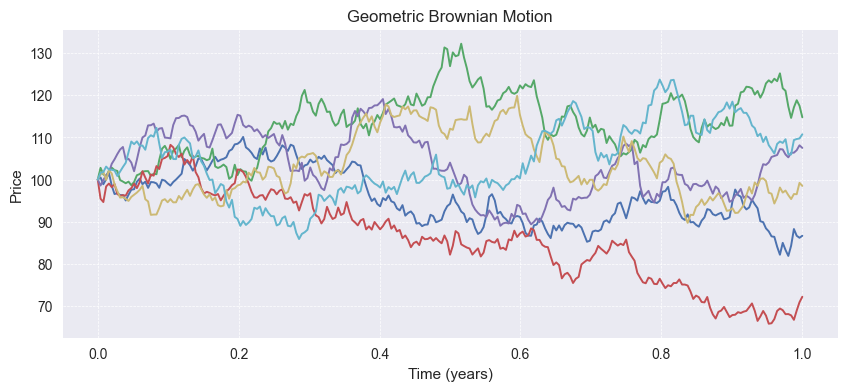

In [4]:
def simulate_gbm(n_steps, horizon=1.0, n_paths=1, s0=1.0, drift=0.0, volatility=0.2, seed=None):
    dt = horizon / n_steps
    rng = np.random.default_rng(seed)
    z = rng.normal(loc=0.0, scale=1.0, size=(n_paths, n_steps))
    log_inc = (drift - 0.5 * volatility**2) * dt + volatility * np.sqrt(dt) * z
    log_paths = np.cumsum(log_inc, axis=1)
    base = np.zeros((n_paths, 1), dtype=float)
    return s0 * np.exp(np.concatenate([base, log_paths], axis=1))


gbm_paths = simulate_gbm(
    n_steps=252,
    horizon=1.0,
    n_paths=6,
    s0=100.0,
    drift=0.08,
    volatility=0.25,
    seed=42,
)

fig, ax = plt.subplots(figsize=(10, 4))
for i in range(gbm_paths.shape[0]):
    ax.plot(time_axis, gbm_paths[i], linewidth=1.4)
ax.set_title("Geometric Brownian Motion")
ax.set_xlabel("Time (years)")
ax.set_ylabel("Price")
ax.grid(True, linestyle="--", linewidth=0.5)
plt.show()

## 4) Drift and Volatility Estimation

$$
r_j = \log\left(\frac{S_{t_{j+1}}}{S_{t_j}}\right),\qquad
\mathbb{E}[r_j]=\left(\alpha-\frac{1}{2}\sigma^2\right)\Delta t,\qquad
\mathrm{Var}(r_j)=\sigma^2\,\Delta t.
$$

Data: AAPL monthly closes from Yahoo Finance. $\Delta t = 1/12$.

Symbol: AAPL  |  24 monthly data points
Estimated annualised drift (alpha):       0.2496
Estimated annualised volatility (sigma):  0.1971


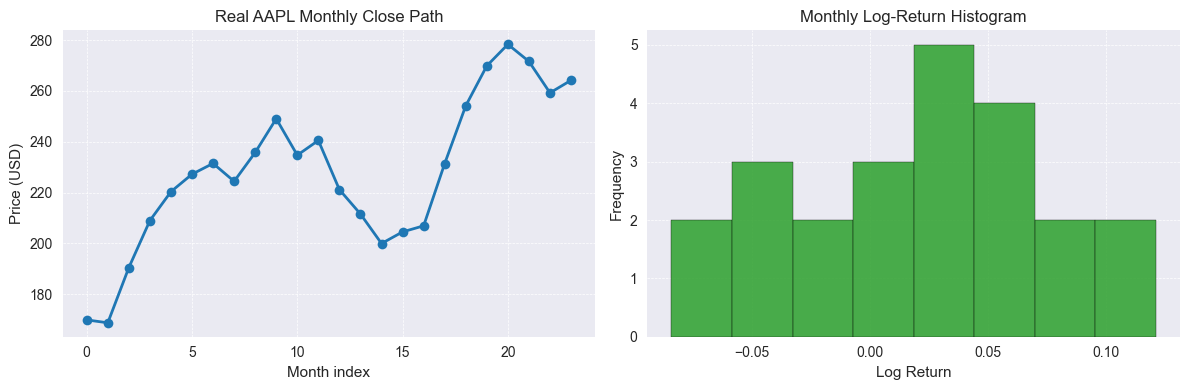

In [5]:
def estimate_drift_and_volatility(prices, dt):
    """Return (alpha, sigma) annualised drift and volatility from price series."""
    arr = np.asarray(prices, dtype=float)
    returns = np.diff(np.log(arr))
    mean_r = float(np.mean(returns))
    var_r = float(np.var(returns, ddof=1))
    sigma2 = max(var_r / dt, 0.0)
    sigma = float(np.sqrt(sigma2))
    alpha = float(mean_r / dt + 0.5 * sigma2)
    return alpha, sigma


# Fetch AAPL monthly closes from Yahoo Finance
symbol = "AAPL"
dt = 1 / 12   # monthly data -> annualise over 12 months

ticker = yf.Ticker(symbol)
hist = ticker.history(period="2y", interval="1mo", auto_adjust=True)
prices = np.asarray(hist["Close"].dropna(), dtype=float)

alpha, sigma = estimate_drift_and_volatility(prices=prices, dt=dt)
returns = np.diff(np.log(prices))

print(f"Symbol: {symbol}  |  {prices.size} monthly data points")
print("Estimated annualised drift (alpha):      ", round(alpha, 4))
print("Estimated annualised volatility (sigma): ", round(sigma, 4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(np.arange(prices.size), prices, color="tab:blue", linewidth=2.0, marker="o")
axes[0].set_title(f"Real {symbol} Monthly Close Path")
axes[0].set_xlabel("Month index")
axes[0].set_ylabel("Price (USD)")
axes[0].grid(True, linestyle="--", linewidth=0.5)

axes[1].hist(returns, bins=8, color="tab:green", alpha=0.85, edgecolor="black")
axes[1].set_title("Monthly Log-Return Histogram")
axes[1].set_xlabel("Log Return")
axes[1].set_ylabel("Frequency")
axes[1].grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

## 3b) GBM Calibrated to Real Market Data

1. Estimate $\alpha$ and $\sigma$ from real AAPL prices (Section 4).
2. Simulate GBM paths with those calibrated parameters.
3. Compare simulated paths against the actual historical path.

Calibrated from AAPL:
  alpha (annualised drift):      0.2496
  sigma (annualised volatility): 0.1971


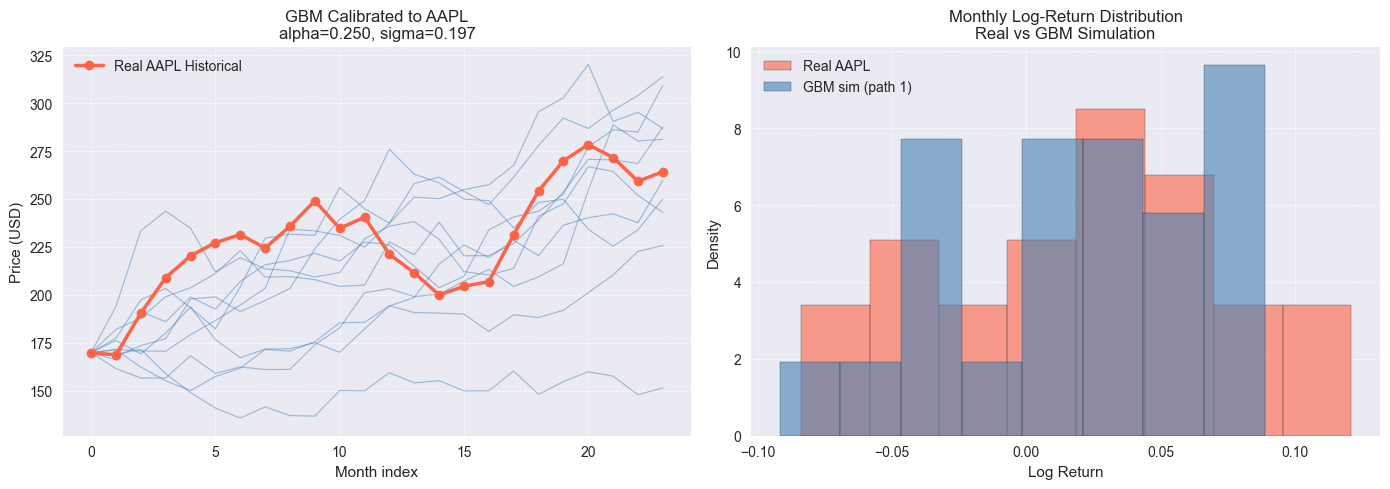


Monthly log-return comparison:
  Real  mean: 0.019184  std: 0.055635
  GBM   mean: 0.018437  std: 0.048031

Note: GBM assumes log-returns are i.i.d. normal.
Any fat tails or skew in the real histogram reveals model limitations.


In [6]:
# --- Step 1: reuse the prices fetched in Section 4 ---
prices_real = prices
n_real = prices_real.size
s0_real = float(prices_real[0])

# --- Step 2: calibrate GBM parameters from real data. ---
drift_real, vol_real = estimate_drift_and_volatility(prices=prices_real, dt=dt)
print(f"Calibrated from {symbol}:")
print(f"  alpha (annualised drift):      {drift_real:.4f}")
print(f"  sigma (annualised volatility): {vol_real:.4f}")

# --- Step 3: simulate GBM paths with calibrated parameters ---
n_sim_paths = 10
gbm_calibrated = simulate_gbm(
    n_steps=n_real - 1,
    horizon=(n_real - 1) / 12,
    n_paths=n_sim_paths,
    s0=s0_real,
    drift=drift_real,
    volatility=vol_real,
    seed=42,
)

# --- Step 4: compare real path vs calibrated simulations ---
month_axis = np.arange(n_real)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overlay simulated paths on real price path
for i in range(n_sim_paths):
    axes[0].plot(month_axis, gbm_calibrated[i], color="steelblue",
                 linewidth=0.8, alpha=0.5)
axes[0].plot(month_axis, prices_real, color="tomato", linewidth=2.5,
             marker="o", label=f"Real {symbol} Historical")
axes[0].set_title(
    f"GBM Calibrated to {symbol}\n"
    f"alpha={drift_real:.3f}, sigma={vol_real:.3f}"
)
axes[0].set_xlabel("Month index")
axes[0].set_ylabel("Price (USD)")
axes[0].legend()
axes[0].grid(True, linestyle="--", linewidth=0.5)

# Right: log-return distribution -- real vs one simulated path
real_returns = np.diff(np.log(prices_real))
sim_returns = np.diff(np.log(gbm_calibrated[0]))

axes[1].hist(real_returns, bins=8, alpha=0.6, color="tomato",
             edgecolor="black", label=f"Real {symbol}", density=True)
axes[1].hist(sim_returns, bins=8, alpha=0.6, color="steelblue",
             edgecolor="black", label="GBM sim (path 1)", density=True)
axes[1].set_title("Monthly Log-Return Distribution\nReal vs GBM Simulation")
axes[1].set_xlabel("Log Return")
axes[1].set_ylabel("Density")
axes[1].legend()
axes[1].grid(True, linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()

# --- goodness-of-fit summary ---
print("\nMonthly log-return comparison:")
print(f"  Real  mean: {real_returns.mean():.6f}  std: {real_returns.std():.6f}")
print(f"  GBM   mean: {sim_returns.mean():.6f}  std: {sim_returns.std():.6f}")
print("\nNote: GBM assumes log-returns are i.i.d. normal.")
print("Any fat tails or skew in the real histogram reveals model limitations.")

## 5) Jump Diffusion

$$
\Delta \log S \approx \left(\alpha - \frac{1}{2}\sigma^2 - \lambda\kappa\right)\Delta t
 + \sigma\sqrt{\Delta t}\,Z + J_{\Delta t},
\qquad
N_{\Delta t} \sim \mathrm{Poisson}(\lambda\,\Delta t).
$$

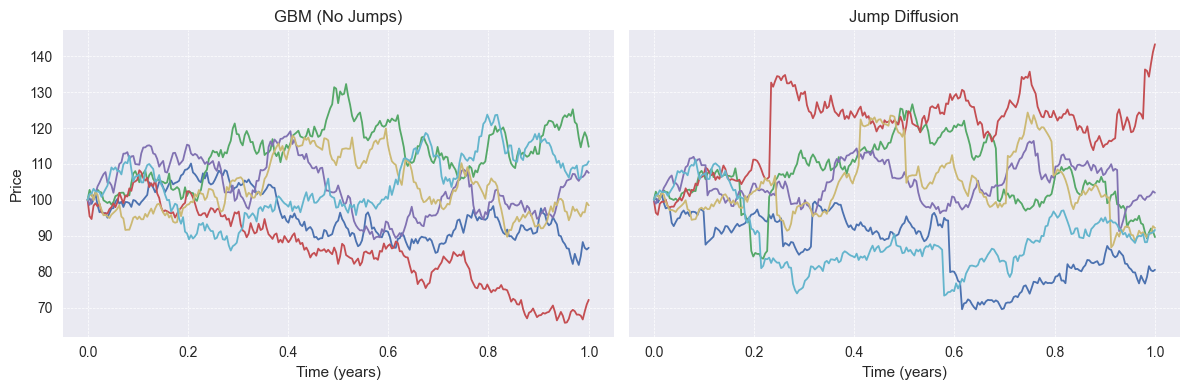

In [7]:
def simulate_jump_diffusion(n_steps, horizon=1.0, n_paths=1, s0=1.0,
                            drift=0.0, volatility=0.2, jump_intensity=1.0,
                            jump_mean=0.0, jump_std=0.1, seed=None):
    dt = horizon / n_steps
    rng = np.random.default_rng(seed)

    z = rng.normal(loc=0.0, scale=1.0, size=(n_paths, n_steps))
    diffusion = volatility * np.sqrt(dt) * z

    n_jumps = rng.poisson(lam=jump_intensity * dt, size=(n_paths, n_steps))
    jump_scale = np.sqrt(n_jumps.astype(float)) * jump_std
    jump_component = rng.normal(loc=n_jumps * jump_mean, scale=jump_scale)

    kappa = np.exp(jump_mean + 0.5 * jump_std**2) - 1.0
    drift_adjusted = drift - 0.5 * volatility**2 - jump_intensity * kappa

    log_inc = drift_adjusted * dt + diffusion + jump_component
    log_paths = np.cumsum(log_inc, axis=1)
    base = np.zeros((n_paths, 1), dtype=float)
    return s0 * np.exp(np.concatenate([base, log_paths], axis=1))


jump_paths = simulate_jump_diffusion(
    n_steps=252,
    horizon=1.0,
    n_paths=6,
    s0=100.0,
    drift=0.08,
    volatility=0.20,
    jump_intensity=6.0,
    jump_mean=-0.03,
    jump_std=0.10,
    seed=42,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for i in range(gbm_paths.shape[0]):
    axes[0].plot(time_axis, gbm_paths[i], linewidth=1.3)
for i in range(jump_paths.shape[0]):
    axes[1].plot(time_axis, jump_paths[i], linewidth=1.3)

axes[0].set_title("GBM (No Jumps)")
axes[1].set_title("Jump Diffusion")
for ax in axes:
    ax.set_xlabel("Time (years)")
    ax.grid(True, linestyle="--", linewidth=0.5)
axes[0].set_ylabel("Price")
plt.tight_layout()
plt.show()